# TikTok Analysis: EDA & Visualization

## Overview

This stage of the analysis focuses on examining and preparing the dataset, building targeted visualizations, and interpreting patterns between claim and opinion videos, with the goal of identifying meaningful features and data characteristics that can inform and support downstream predictive modeling.

## Key Insights

* Claim videos account for a much larger share of total views despite similar counts to opinion videos, showing that they reach a wider audience.
* Higher engagement, especially view count, is consistently tied to claim content, making it a strong signal for distinguishing claim versus opinion videos.
* Authors who post claim videos are more likely to be under review or banned, suggesting a clear link between claim content and moderation outcomes.
* Verified users are more likely to post opinion videos, indicating that account status may influence the type of content being shared.
* Engagement data is heavily skewed by a small number of high-performing videos, meaning outliers will need to be handled carefully in any predictive model.

## Import & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("data/tiktok_dataset.csv")

## Data Inspection

In [3]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Categorical variables such as `claim_status`, `verified_status`, and `author_ban_status` are present and will be important for grouping and comparison during analysis.

In [4]:
print(f"✅ Dataset loaded: {data.shape[0]:,} rows × {data.shape[1]} columns")

✅ Dataset loaded: 19,382 rows × 12 columns


The dataset contains 19,382 entries and 12 variables, indicating a moderately sized dataset that is large enough for meaningful analysis while still manageable for exploratory work.

In [5]:
data.size

232584

In [6]:
# Basic information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  str    
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  str    
 5   verified_status           19382 non-null  str    
 6   author_ban_status         19382 non-null  str    
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), str(4)
memory usage: 1.8 MB


In [10]:
missing_pct = (data.isna().sum().sum() / data.size) * 100
print(f"Total missing data: {missing_pct:.2f}%")

Total missing data: 0.90%


* Several key fields (including `claim_status`, engagement metrics, and transcription text) have missing values, suggesting that data cleaning or filtering will be required before building any reliable analysis or model.
* The dataset appears structurally consistent with no obvious data type issues and minimal missing values(0.90% of total data) suggesting it is already well prepared for initial analysis aside from handling missing values.

In [7]:
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


* Engagement related variables (views, likes, shares, downloads, comments) are stored as numerical values with wide ranges, indicating high variability and the likely presence of outliers.
* The large gap between median and maximum values across engagement metrics suggests a heavily right-skewed distribution, where a small number of videos receive disproportionately high engagement.

## Visualization

Box plots and histograms are useful for understanding how the data is distributed, which helps identify patterns, skewness, and outliers, informing how the data should be handled in downstream analysis and modeling.

### video_duration_sec

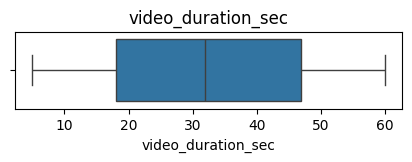

In [12]:
# Boxplot visualizing 'video_duration_sec'
plt.figure(figsize=(5,1))
plt.title('video_duration_sec')
sns.boxplot(x=data['video_duration_sec']);

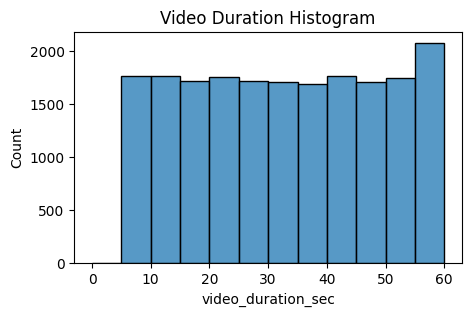

In [13]:
# Histogram of `video_duration_sec` distribution
plt.figure(figsize=(5,3))
sns.histplot(data['video_duration_sec'], bins=range(0,61,5))
plt.title('Video Duration Histogram');

A fairly uniform spread that is unlikely to be a strong differentiator between claim and opinion content

### video_view_count

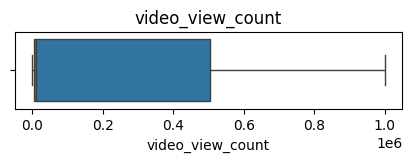

In [14]:
# Boxplot visualizing `video_view_count` distribution
plt.figure(figsize=(5,1))
plt.title('video_view_count')
sns.boxplot(x=data['video_view_count']);

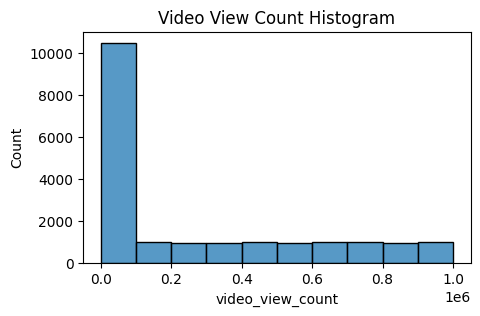

In [16]:
# Histogram of `video_view_count`
plt.figure(figsize=(5,3))
sns.histplot(data['video_view_count'], bins=range(0,(10**6+1),10**5))
plt.title('Video View Count Histogram');

### Key Insight

The histogram shows a strong right skew, where most values are concentrated at the lower end and a small number of observations extend into very high values, indicating the presence of outliers.

### video_like_count

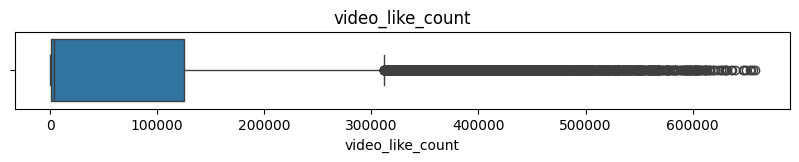

In [17]:
# Boxplot for `video_like_count` values
plt.figure(figsize=(10,1))
plt.title('video_like_count')
sns.boxplot(x=data['video_like_count']);

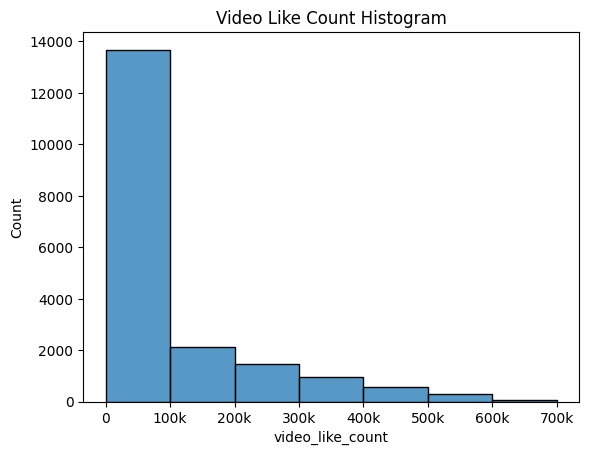

In [20]:
# Histogram for `video_like_count' distribution
ax = sns.histplot(data['video_like_count'], bins=range(0,(7*10**5+1),10**5))
labels = [0] + [str(i) + 'k' for i in range(100,701, 100)]
ax.set_xticks(range(0,7*10**5+1,10**5), labels=labels)
plt.title('Video Like Count Histogram');

Most videos have fewer than 100,000 likes, with the number of videos gradually decreasing as like counts increase, showing a right-skewed distribution where a smaller group of videos reaches very high like counts.

### video_comment_count

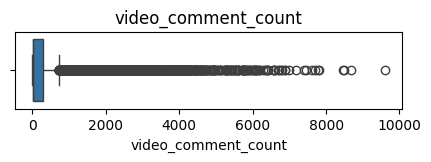

In [21]:
# boxplot visualizing `video_comment_count` distribution
plt.figure(figsize=(5,1))
plt.title('video_comment_count')
sns.boxplot(x=data['video_comment_count']);

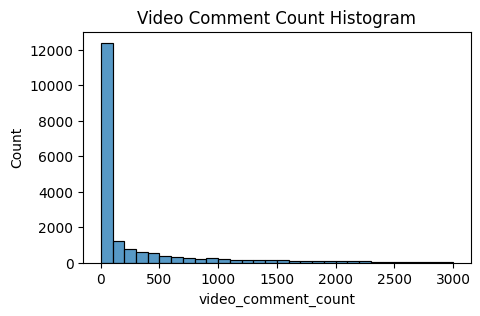

In [22]:
# Histogram of `video_comment_count` value distribution
plt.figure(figsize=(5,3))
sns.histplot(data['video_comment_count'], bins=range(0,(3001),100))
plt.title('Video Comment Count Histogram');

Most videos have very low comment counts, with the majority falling under 100, while a small number of videos receive much higher engagement, resulting in another strongly right skewed distribution.

### video_share_count

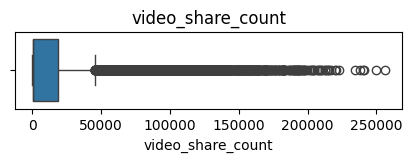

In [23]:
# Boxplot visualizing `video_share_count` values
plt.figure(figsize=(5,1))
plt.title('video_share_count')
sns.boxplot(x=data['video_share_count']);

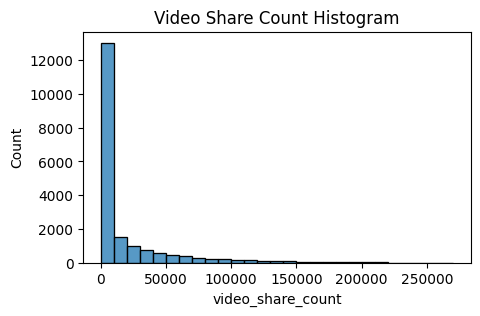

In [24]:
# Histogram of `video_share_count` distribution
plt.figure(figsize=(5,3))
sns.histplot(data['video_share_count'], bins=range(0,(270001), 10000))
plt.title('Video Share Count Histogram');

Most videos have relatively low share counts, with the majority under 10,000, while a small number of videos reach much higher values, resulting in another strongly right skewed distribution.

### video_download_count

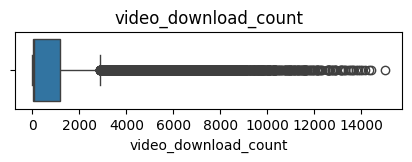

In [25]:
# Boxplot visualizing `video_download_count` values
plt.figure(figsize=(5,1))
plt.title('video_download_count')
sns.boxplot(x=data['video_download_count']);

Text(0.5, 1.0, 'Video Download Count Histogram')

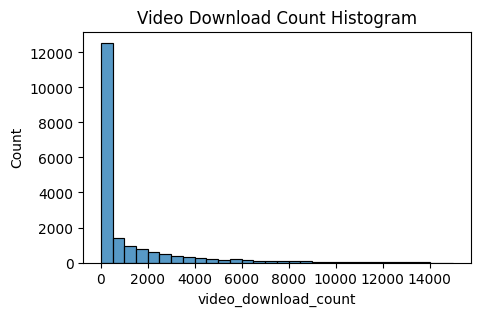

In [26]:
# Histogram of `video_download_count` distribution
plt.figure(figsize=(5,3))
sns.histplot(data['video_download_count'], bins=range(0,(15001),500))
plt.title('Video Download Count Histogram')

Again, another severely right skewed distribution strongly highlighting the presence of outliers

### Claim Status by Verification Status

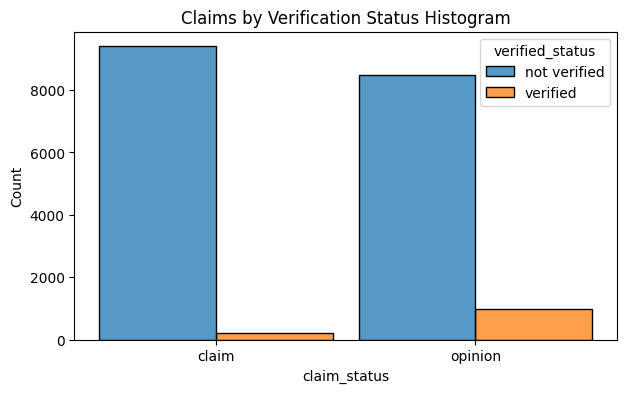

In [27]:
# Histogram for each combination of claim status and verification
plt.figure(figsize=(7,4))
sns.histplot(data=data,
             x='claim_status',
             hue='verified_status',
             multiple='dodge',
             shrink=0.9)
plt.title('Claims by Verification Status Histogram');

There are significantly fewer verified users compared to unverified users, but verified users are more likely to post opinion content rather than claims.

### Claim Status by Author Ban Status

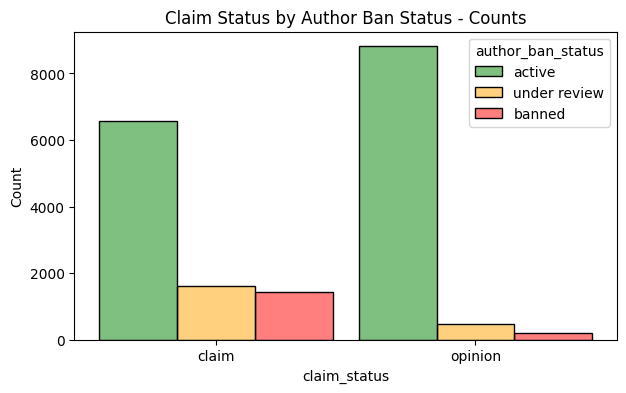

In [30]:
# Histogram of each claim status for each ban status using the groupby() method
fig = plt.figure(figsize=(7,4))
sns.histplot(data, x='claim_status', hue='author_ban_status',
             multiple='dodge',
             hue_order=['active', 'under review', 'banned'],
             shrink=0.9,
             palette={'active':'green', 'under review':'orange', 'banned':'red'},
             alpha=0.5)
plt.title('Claim Status by Author Ban Status - Counts');

Most authors are active regardless of content type, but the share of active authors is noticeably higher for opinion videos, while claim videos are more likely to be associated with authors who are under review or banned.

### Median View Counts by Ban Status

<Axes: xlabel='author_ban_status', ylabel='video_view_count'>

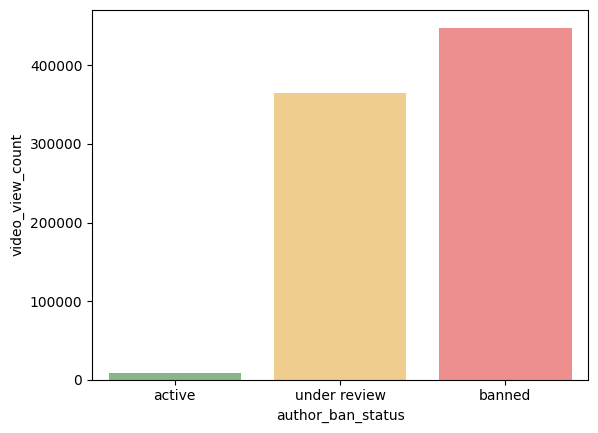

In [32]:
# Bar plot
sns.barplot(
    data=ban_status_counts,
    x='author_ban_status',
    y='video_view_count',
    hue='author_ban_status',
    order=['active', 'under review', 'banned'],
    palette={'active':'green', 'under review':'orange', 'banned':'red'},
    legend=False,
    alpha=0.5
)

In [33]:
# Quick check
data.groupby('claim_status')['video_view_count'].median()

claim_status
claim      501555.0
opinion      4953.0
Name: video_view_count, dtype: float64

Median view counts are much higher for authors who are `under review` or `banned` compared to `active authors`, and since these authors are more likely to post claim content, `video_view_count` may be a useful indicator for distinguishing claim versus opinion videos.

### Total Views by Claim Status

Text(0.5, 1.0, 'Total views by video claim status')

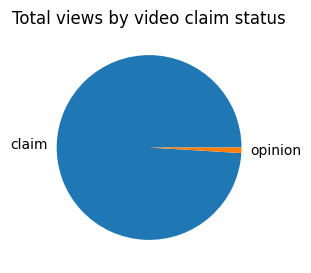

In [34]:
# Create pie chart for total views by claim status
fig = plt.figure(figsize=(3, 3))

plt.pie(
    data.groupby('claim_status')['video_view_count'].sum(),
    labels=['claim', 'opinion']
)

plt.title('Total views by video claim status')

Claim videos account for most of the total views despite there being a similar number of claim and opinion videos in the dataset.

## Identifying Outliers

Outliers can affect predictive models by skewing results, especially when a small number of videos have extremely high engagement. In this dataset, these high values appear consistent with expected social media behavior rather than data errors, and since engagement is closely related to claim status, these patterns should be considered carefully rather than blatantly removed.

One approach to define outliers is using the median plus 1.5 times the interquartile range (IQR), where the IQR represents the spread between the 25th and 75th percentiles and the 1.5 multiplier is a common threshold for identifying extreme values. In this case, using the median instead of the third quartile results in a lower cutoff for detecting outliers.

In [36]:
# For loop iterating over column names of each count variable
count_cols = ['video_view_count',
              'video_like_count',
              'video_share_count',
              'video_download_count',
              'video_comment_count',
              ]

for column in count_cols:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    median = data[column].median()
    outlier_threshold = median + 1.5*iqr

# Count outliers exceeding threshold
outlier_count = (data[column] > outlier_threshold).sum()
print(f"Number of outliers, {column}:", outlier_count)

Number of outliers, video_comment_count: 3882


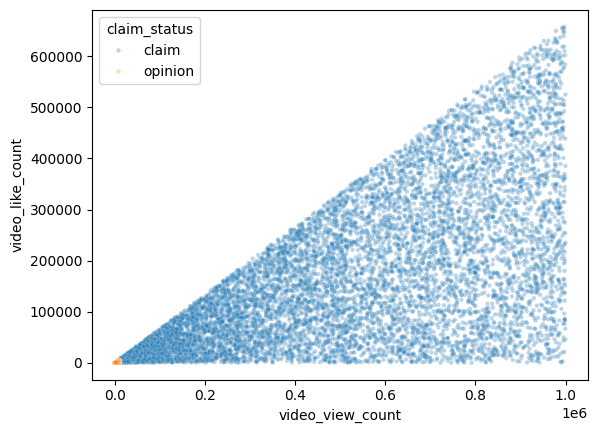

In [37]:
# Scatterplot of `video_view_count` vs `video_like_count` by `claim_status`
sns.scatterplot(x=data["video_view_count"], y=data["video_like_count"],
                hue=data["claim_status"], s=10, alpha=.3)
plt.show()

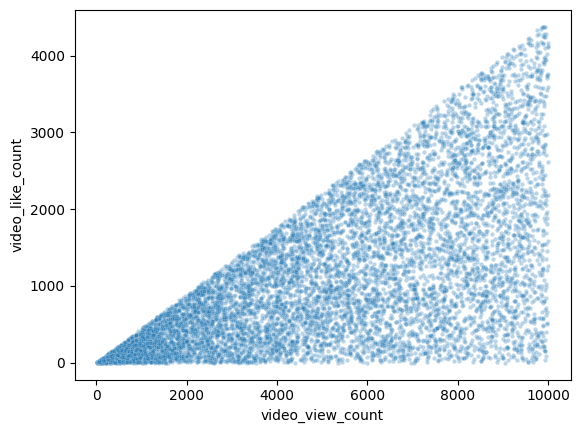

In [38]:
# Scatterplot of `video_view_count` vs `video_like_count` (opinons only)
opinion = data[data['claim_status']=='opinion']
sns.scatterplot(x=opinion["video_view_count"], y=opinion["video_like_count"],
                s=10, alpha=.3)
plt.show()

* The data distribution, counts, central tendencies, and outliers were examined, and relationships between key variables, particularly engagement metrics, and claim status were analyzed.

* Further analysis is needed to identify characteristics that clearly distinguish claim videos from opinion videos and to determine whether additional variables could improve that separation.

* Stakeholders are likely interested in variables that are most useful for predicting claim status and the assumptions behind how those variables are used in the model.